In [ ]:
#packages
import os
from openslide import open_slide
import openslide
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL as Image
from pathlib import Path
import json

import os
import glob
import shutil

import logging
if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()

# pprint
from pprint import pprint

import matplotlib as mpl

from tiatoolbox import logger
# from tiatoolbox import small_svs
from tiatoolbox.wsicore.wsireader import WSIReader
from tiatoolbox.annotation.storage import Annotation

mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'font.size': 5})


## 0. Slide Selector

In [2]:
# Update path to local Data folder
drive_folder = r'c:\Users\swowg\Desktop\Master HCAI\HCAI - UMCU\Model\Data'

#alle slides van extension .ndpi
file_list = glob.glob(os.path.join(drive_folder, '*.ndpi'))

#validatiecheck
if len(file_list) == 0:
    print("Geen geldige .ndpi file! Check directory.")
    print(f"Checked directory: {drive_folder}")
    print(f"Directory exists: {os.path.exists(drive_folder)}")
else:
    print(f"Found {len(file_list)} slides:")
    for index, filename in enumerate(file_list):
        print(f"[{index}] {os.path.basename(filename)}")

    #slideselector
    #[0] = eerste slide, [1] tweede slide, etc...
    selection_index = 0  

    selected_file_path = file_list[selection_index]
    local_filename = "current_slide.ndpi"

    #laden
    print(f"\nLoading: {os.path.basename(selected_file_path)}...")
    shutil.copy(selected_file_path, local_filename)
    slide = open_slide(local_filename)

    print("Gelukt! Slide ready voor analyse.")

Found 5 slides:
[0] morpho_001_1_1.ndpi
[1] morpho_002_1_1.ndpi
[2] morpho_003_1_1.ndpi
[3] morpho_004_1_1.ndpi
[4] morpho_005_1_1.ndpi

Loading: morpho_001_1_1.ndpi...
Gelukt! Slide ready voor analyse.


### 1. Thumbnail


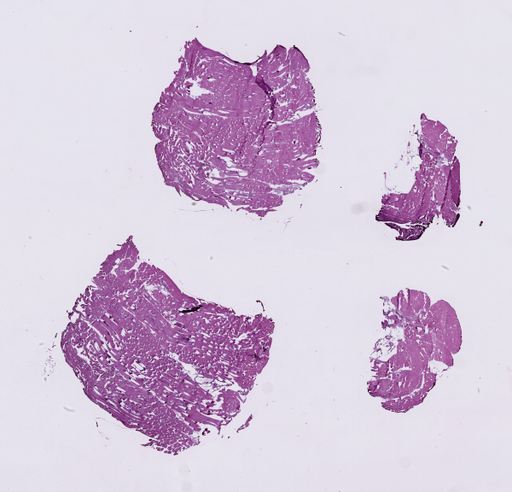

In [3]:
thumbnail = slide.get_thumbnail((512, 512)) #specificeer pixels (x,y)
display(thumbnail)

## 2. Metadata

**Definitions (https://tia-toolbox.readthedocs.io/en/stable/_autosummary/tiatoolbox.wsicore.wsimeta.WSIMeta.html)**

Scale
- `mpp-x:` µm/pixel (µm per 1 pixel in width)
- `mpp-y:` µm/pixel (µm per 1 pixel in height)

Objective Power/Magnification level (examples):
- `20x:` Lower resolution (lower mpp)
- `40x:` Higher resolution (bigger mpp)

Vendor (scanner):
- `Hamamatsu:` Slides were digitized using a Hamamatsu scanner.

Pyramid levels/downsamples:
- `Level 0:` Highest resolution/original scan/huge mpp-x/mpp-y (µm per pixel-x-y)
- `Level 0+n:` Lower resolution/usually 2x lower per level
- `e.g.:` Level 0 = 0.25 µm/pixel, level 1 = 0.50 µm/pixel, level 2 = 1.00 µm/pixel


In [4]:
#defining properties 

dimensions = slide.dimensions
level_count = slide.level_count
downsamples = slide.level_downsamples
level_dimensions = slide.level_dimensions

mpp_x = slide.properties.get("openslide.mpp-x")
mpp_y = slide.properties.get("openslide.mpp-y")
objective = slide.properties.get("openslide.objective-power")
vendor = slide.properties.get("openslide.vendor")


In [5]:
#create dataframe with all WSI properties
wsi_properties = {
    "Property": [
        "Dimensions",
        "Level Count",
        "Downsamples",
        "Level Dimensions",
        "mpp-X (µm/pixel)",
        "mpp-Y (µm/pixel)",
        "Objective Power",
        "Vendor"
    ],
    "Value": [
        dimensions,
        level_count,
        downsamples,
        level_dimensions,
        mpp_x,
        mpp_y,
        objective,
        vendor
    ]
}

df_wsi = pd.DataFrame(wsi_properties)
display(df_wsi)

,Property,Value
0,Dimensions,"(76800, 73728)"
1,Level Count,9
2,Downsamples,"(1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, ..."
3,Level Dimensions,"((76800, 73728), (38400, 36864), (19200, 18432..."
4,mpp-X (µm/pixel),0.22984807042544877
5,mpp-Y (µm/pixel),0.22986392055902904
6,Objective Power,40
7,Vendor,hamamatsu


**Properties**

`Dimensions`
The dimensions of the slide at the highest resolution level (level 0), expressed in pixels. This represents the full spatial extent of the scanned tissue at native resolution.

`Level Count`
The number of resolution levels available in the image pyramid. Each level represents the same tissue content at a progressively lower spatial resolution.

`Downsamples`
The downsampling factors associated with each pyramid level relative to the base level. A factor of 2 indicates that both width and height are reduced by half compared to the previous level, resulting in approximately four times fewer pixels.

`Level Dimensions`
The image dimensions (width × height in pixels) at each pyramid level. These values correspond to the base dimensions scaled by the respective downsampling factors.

`mpp-X (µm/pixel)`
The physical pixel spacing in the horizontal direction, expressed in micrometers per pixel. This value defines how much real-world tissue distance is represented by a single pixel.

`mpp-Y (µm/pixel)`
The physical pixel spacing in the vertical direction, expressed in micrometers per pixel. Together with mpp-X, this determines the spatial scale of the image.

`Objective Power`
The magnification of the microscope objective used during slide digitization. An objective power of 40× corresponds to high-resolution scanning suitable for cellular and nuclear analysis.

`Vendor`
The manufacturer of the whole-slide scanner used to digitize the tissue slide (Hamamatsu). This information is relevant for reproducibility and interpretation of scanner-specific metadata.

In [6]:
#RGBA + Transparency (how transparent is a pixel?) (4 color channels -> this is a property of OpenSlide, as OpenSlide uses RGBA format for regions)
region = slide.read_region((0, 0), 0, (512, 512))
region.mode

'RGBA'

## 3. Application TIAToolbox WSI

In [7]:
reader = WSIReader.open(local_filename)
print(reader)

In [8]:
#current, loaded slide
info_dict = reader.info.as_dict()
pprint(info_dict)

{'axes': 'YXS',
 'file_path': WindowsPath('current_slide.ndpi'),
 'level_count': 9,
 'level_dimensions': ((76800, 73728),
                      (38400, 36864),
                      (19200, 18432),
                      (9600, 9216),
                      (4800, 4608),
                      (2400, 2304),
                      (1200, 1152),
                      (600, 576),
                      (300, 288)),
 'level_downsamples': [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0],
 'mpp': (0.22984807042544877, 0.22986392055902904),
 'objective_power': 40.0,
 'slide_dimensions': (76800, 73728),
 'vendor': 'hamamatsu'}


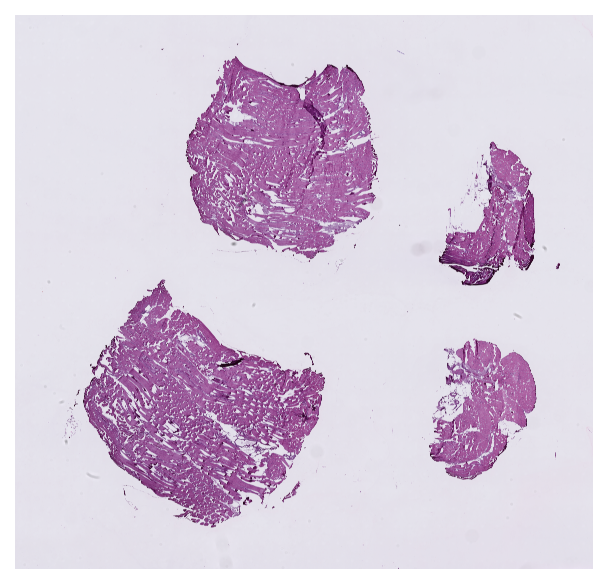

In [9]:
thumbnail = reader.slide_thumbnail(resolution = 1.25, units = 'mpp')
plt.imshow(thumbnail)
plt.axis('off')
plt.show()

Reading WSI regions (read_rect)

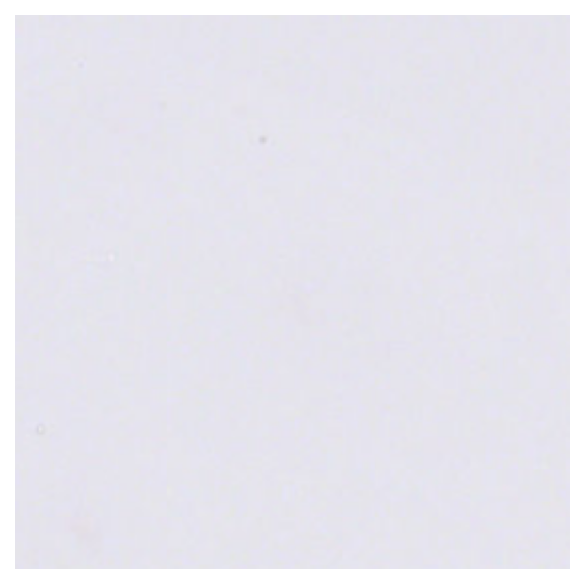

In [10]:
#locations coordinates in (x, y) format
location = (1000, 1000)

#size of the region in (width, height) format
size = (256, 256)

#read region using wsi's read rect at 0.5 mpp
img = reader.read_rect(
    location,
    size,
    resolution = 0.5,
    units = 'mpp',
)

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# Path to annotation JSON file and WSI file
annotation_path = "path/to/morpho_annotations/morpho_001_1_1_annotation.json"
wsi_path = "path/to/morpho_001_1_1.ndpi"

# Load the annotations
annotations = Annotation.from_json(annotation_path)

# Load the corresponding WSI
wsi = WSIReader.open(wsi_path)

# Visualize the WSI with annotations
fig, ax = plt.subplots(figsize = (10, 10))
ax.imshow(wsi.slide_thumbnail(resolution = 1.25))  # Load a thumbnail of the WSI
annotations.draw(ax=ax, resolution = 1.25)  # Overlay annotations
plt.show()

# Inspect a specific annotation
for idx, annotation in enumerate(annotations):
    print(f"Annotation {idx}: {annotation}")
    if idx == 0:  # Example: Look at the first annotation
        print("Geometry:", annotation.geometry)
        print("Properties:", annotation.properties)

: 